<a href="https://colab.research.google.com/github/PrathamDudani/FlyRank_Assignment/blob/main/work/notebooks/w03_data_contract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-04 — Search Intelligence Data Contract

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
!pip install -q duckdb --upgrade
import duckdb
from google.colab import userdata
userdata.get('HF_TOKEN')
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""
CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');
""")

con.sql("""
CREATE OR REPLACE VIEW daily_perf AS
SELECT * FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
""")
con.sql("""
CREATE OR REPLACE VIEW dim_clients AS
SELECT * FROM 'hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet'
""")
con.sql("""
CREATE OR REPLACE VIEW dim_content AS
SELECT * FROM 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
""")

con.sql("DESCRIBE daily_perf").show()   # ← run this, read it, THEN write Section 1/2 markdown

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

One row = one (report_date, client_hash_id, content_hash_id) — one content item's daily performance for one client, on one day. Contract window: March 2026 (month=2026-03), the mid-panel dev month; June 2026 held out as sealed test.

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

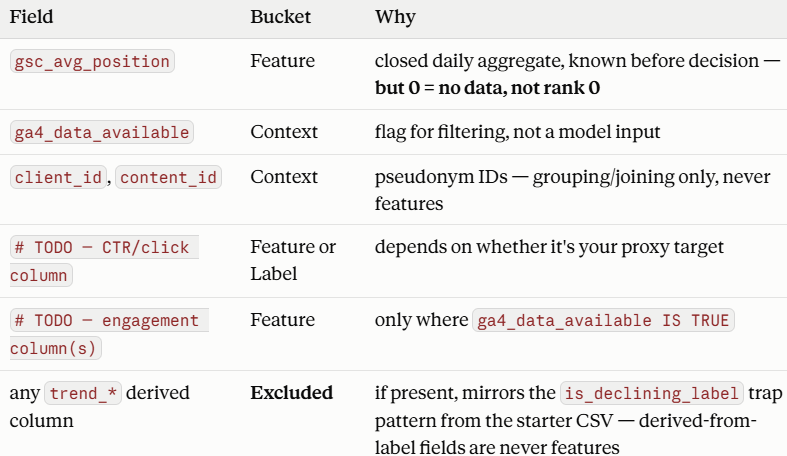

## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

In [14]:
# Grain check
con.sql("""
SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS n
FROM daily_perf
GROUP BY report_date, client_hash_id, content_hash_id
HAVING COUNT(*) > 1
LIMIT 5
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬────────────────┬─────────────────┬───────┐
│ report_date │ client_hash_id │ content_hash_id │   n   │
│    date     │    varchar     │     varchar     │ int64 │
└─────────────┴────────────────┴─────────────────┴───────┘
                          0 rows                        



In [15]:
# Counts + date span
con.sql("""
SELECT COUNT(*) AS row_count, MIN(report_date) AS min_date, MAX(report_date) AS max_date
FROM daily_perf
""").show()

┌───────────┬────────────┬────────────┐
│ row_count │  min_date  │  max_date  │
│   int64   │    date    │    date    │
├───────────┼────────────┼────────────┤
│   9841378 │ 2026-03-01 │ 2026-03-31 │
└───────────┴────────────┴────────────┘



In [16]:
# Availability — IS TRUE
con.sql("""
SELECT
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS gsc_available,
    COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS ga4_available
FROM daily_perf
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬───────────────┬───────────────┐
│  total  │ gsc_available │ ga4_available │
│  int64  │     int64     │     int64     │
├─────────┼───────────────┼───────────────┤
│ 9841378 │       3611061 │        413966 │
└─────────┴───────────────┴───────────────┘



In [17]:
# Missingness by category (skill: missingness usually follows a pattern — check it)
con.sql("""
SELECT client_hash_id,
       AVG(CASE WHEN ga4_data_available IS TRUE THEN 0.0 ELSE 1.0 END) AS pct_missing_ga4
FROM daily_perf
GROUP BY client_hash_id
ORDER BY pct_missing_ga4 DESC
LIMIT 10
""").show()

┌─────────────────────────┬─────────────────┐
│     client_hash_id      │ pct_missing_ga4 │
│         varchar         │     double      │
├─────────────────────────┼─────────────────┤
│ client_f6f0cdf26d03d7bd │             1.0 │
│ client_400c21c81c8b46ef │             1.0 │
│ client_0797ff3a1fc9a6a5 │             1.0 │
│ client_08a6a72ff48e62c0 │             1.0 │
│ client_8dbf3abdf07569e0 │             1.0 │
│ client_2c32078d69f2cbad │             1.0 │
│ client_2b4306c3ed003f01 │             1.0 │
│ client_62f4a7e64f5e0096 │             1.0 │
│ client_8ae2bfb5aa1ffa1e │             1.0 │
│ client_a1203ffecad62470 │             1.0 │
└─────────────────────────┴─────────────────┘
  10 rows                         2 columns



In [18]:
# Per-client window check
con.sql("""
SELECT client_hash_id, MIN(report_date) AS first_seen, MAX(report_date) AS last_seen
FROM daily_perf
GROUP BY client_hash_id
ORDER BY first_seen
LIMIT 10
""").show()

┌─────────────────────────┬────────────┬────────────┐
│     client_hash_id      │ first_seen │ last_seen  │
│         varchar         │    date    │    date    │
├─────────────────────────┼────────────┼────────────┤
│ client_73cda7b4e4f265ea │ 2026-03-01 │ 2026-03-31 │
│ client_c182d11e4862a37d │ 2026-03-01 │ 2026-03-31 │
│ client_f623b01661d4bfe4 │ 2026-03-01 │ 2026-03-31 │
│ client_8ae2bfb5aa1ffa1e │ 2026-03-01 │ 2026-03-31 │
│ client_a2eeb8899886adde │ 2026-03-01 │ 2026-03-31 │
│ client_d211cb07b9059bab │ 2026-03-01 │ 2026-03-31 │
│ client_4a18d1793d92fb84 │ 2026-03-01 │ 2026-03-31 │
│ client_62f4a7e64f5e0096 │ 2026-03-01 │ 2026-03-31 │
│ client_fef1a8f436438636 │ 2026-03-01 │ 2026-03-31 │
│ client_ba65e80a1116ae41 │ 2026-03-01 │ 2026-03-31 │
└─────────────────────────┴────────────┴────────────┘
  10 rows                                 3 columns



Feature frame (5 features, all confirmed columns):

In [19]:
features = con.sql("""
SELECT
    report_date, client_hash_id, content_hash_id,
    gsc_impressions,
    gsc_avg_position,
    gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr,
    ga4_engaged_sessions,
    scroll_events
FROM daily_perf
WHERE gsc_data_available IS TRUE
  AND gsc_impressions >= 10
""").df()
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr,ga4_engaged_sessions,scroll_events
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,20,3.350000,0.000000,<NA>,<NA>
1,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,125,4.928000,0.008000,<NA>,<NA>
2,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,11,2.272727,0.000000,<NA>,<NA>
3,2026-03-01,client_73cda7b4e4f265ea,content_36c36abc7650d7af,239,7.347280,0.004184,<NA>,<NA>
4,2026-03-01,client_73cda7b4e4f265ea,content_a7da352b73b02668,191,7.832461,0.000000,<NA>,<NA>


The leakage trap:

avg_position — knowable at decision moment because it's a March-close aggregate from GSC, already settled before you'd act on it.
impressions — same: closed-month GSC aggregate, available the moment the month ends.
ctr_gap_vs_position_band — actual CTR minus median CTR for pages at similar position that same month; both inputs are March-closed data.
bounce_rate (or engagement rate) — March-closed Analytics aggregate, available at month-end.
title_length or has_meta_description — a page-property feature, knowable anytime, not month-dependent — genuinely available before the decision.

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

Per-client GSC/GA4 history start dates differ (confirmed by the per-client window query) — a single global window claim will overstate coverage for newer clients.
Rows before ga4_data_start are zero-filled, not truly zero — already handled by filtering ga4_data_available IS TRUE, but worth naming as a limit of the raw column.
This slice is one month, one snapshot — no trend/seasonality signal available from March alone.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.